In [160]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np


### 1.Perform exploratory data analysis (EDA) to gain insights into the dataset. Provide visualizations and summary statistics of the variables. Pre process the data to apply the MLR.

In [161]:
df = pd.read_csv("ToyotaCorolla - MLR.csv")

In [162]:
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [163]:
df.info

<bound method DataFrame.info of       Price  Age_08_04     KM Fuel_Type   HP  Automatic    cc  Doors  \
0     13500         23  46986    Diesel   90          0  2000      3   
1     13750         23  72937    Diesel   90          0  2000      3   
2     13950         24  41711    Diesel   90          0  2000      3   
3     14950         26  48000    Diesel   90          0  2000      3   
4     13750         30  38500    Diesel   90          0  2000      3   
...     ...        ...    ...       ...  ...        ...   ...    ...   
1431   7500         69  20544    Petrol   86          0  1300      3   
1432  10845         72  19000    Petrol   86          0  1300      3   
1433   8500         71  17016    Petrol   86          0  1300      3   
1434   7250         70  16916    Petrol   86          0  1300      3   
1435   6950         76      1    Petrol  110          0  1600      5   

      Cylinders  Gears  Weight  
0             4      5    1165  
1             4      5    1165  
2   

In [164]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [165]:
df.shape

(1436, 11)

In [166]:
df.columns

Index(['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc',
       'Doors', 'Cylinders', 'Gears', 'Weight'],
      dtype='object')

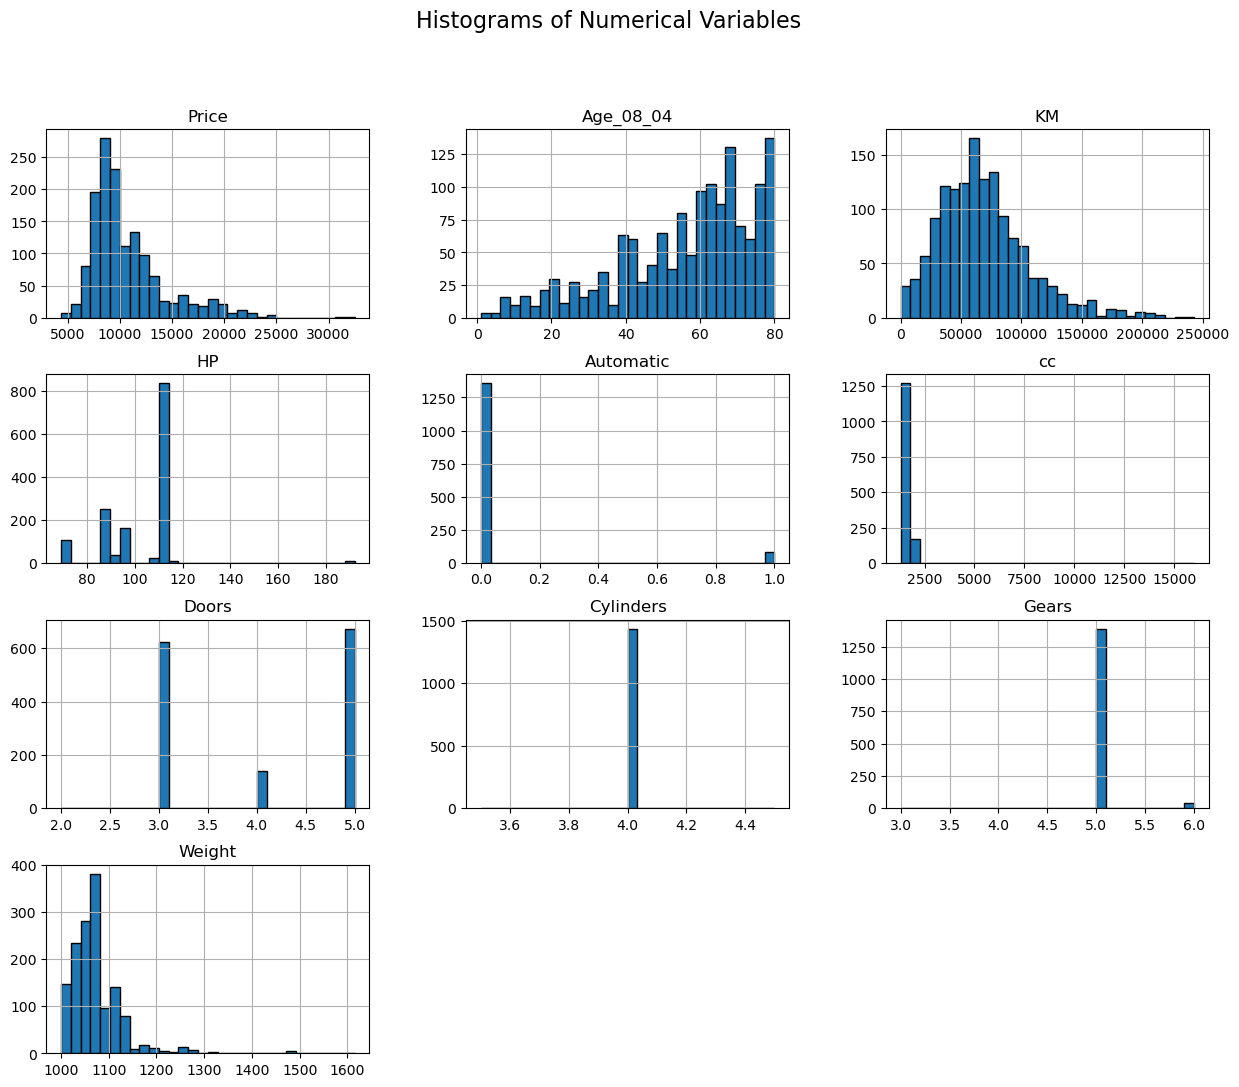

In [167]:
# providing visualisation
df.hist(bins=30, figsize=(15, 12), edgecolor='black')
plt.suptitle("Histograms of Numerical Variables", fontsize=16)
plt.show()

In [168]:
# Handling missing values
df.isna().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [169]:
# checking for duplicates
df.duplicated().sum()

np.int64(1)

In [170]:
# handling duplicates
df.drop_duplicates(inplace=True,ignore_index = True)

In [171]:
df.duplicated().sum()

np.int64(0)

In [172]:
# rename
df = df.rename(columns={'Age_08_04':'Age'})

<Axes: >

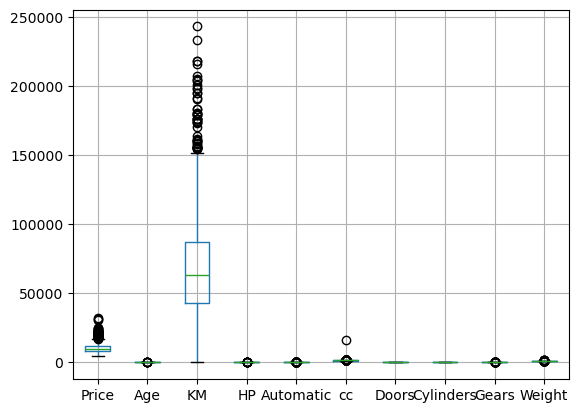

In [173]:
# outliers check
df.boxplot()

In [174]:
# outliners removing
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Treat (cap) outliers
    df[col] = df[col].clip(lower, upper)

print("Outliers detected and treated successfully.")

Outliers detected and treated successfully.


<Axes: >

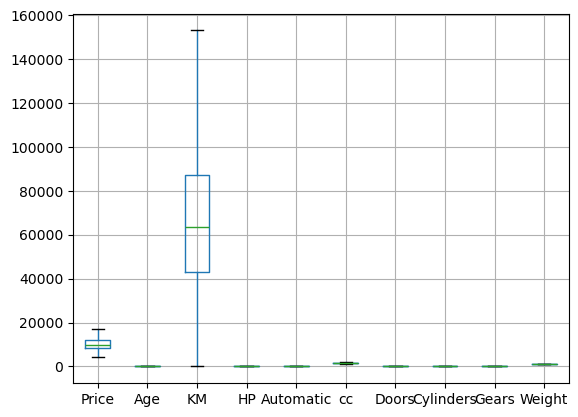

In [175]:
df.boxplot()

In [176]:
# cat to dummy:
df = pd.get_dummies(df,columns=["Fuel_Type"],drop_first=False)

df = df.drop(columns=['Fuel_Type_Petrol'])

In [177]:
df.head()

,Price,Age,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_CNG,Fuel_Type_Diesel
0,13500,23,46986.0,90,0,1900,3,4,5,1152.5,False,True
1,13750,23,72937.0,90,0,1900,3,4,5,1152.5,False,True
2,13950,24,41711.0,90,0,1900,3,4,5,1152.5,False,True
3,14950,26,48000.0,90,0,1900,3,4,5,1152.5,False,True
4,13750,30,38500.0,90,0,1900,3,4,5,1152.5,False,True


In [178]:
# Define Target Variable
Y = df['Price']
# define Predictor Variables
X = df[['Age','KM','HP','Automatic','cc','Doors','Cylinders','Gears','Weight','Fuel_Type_CNG','Fuel_Type_Diesel']]

### 2.Split the dataset into training and testing sets (e.g., 80% training, 20% testing).


In [179]:
Y.head()

0    13500
1    13750
2    13950
3    14950
4    13750
Name: Price, dtype: int64

In [180]:
X.head()

,Age,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_CNG,Fuel_Type_Diesel
0,23,46986.0,90,0,1900,3,4,5,1152.5,False,True
1,23,72937.0,90,0,1900,3,4,5,1152.5,False,True
2,24,41711.0,90,0,1900,3,4,5,1152.5,False,True
3,26,48000.0,90,0,1900,3,4,5,1152.5,False,True
4,30,38500.0,90,0,1900,3,4,5,1152.5,False,True


In [181]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


x_train,x_test,Y_train,Y_test = train_test_split(X,Y,train_size = 0.80,random_state = 10)


In [182]:
x_train.shape , x_test.shape , Y_train.shape , Y_test.shape

((1148, 11), (287, 11), (1148,), (287,))

### 3.Build a multiple linear regression model using the training dataset. Interpret the coefficients of the model. Build minimum of 3 different models.


In [183]:
# build the Model
lreg = LinearRegression()

In [184]:
# Train the model
lreg.fit(x_train,Y_train)

LinearRegression()

In [185]:
# baseline
lreg.intercept_


np.float64(-6356.449200153951)

In [188]:
# Interpret the coefficient of the model
print(x_train.columns)

lreg.coef_

Index(['Age', 'KM', 'HP', 'Automatic', 'cc', 'Doors', 'Cylinders', 'Gears',
       'Weight', 'Fuel_Type_CNG', 'Fuel_Type_Diesel'],
      dtype='object')


array([-1.07840995e+02, -1.39874362e-02,  2.45509079e+01,  2.13162821e-14,
       -2.06230123e+00, -9.73966099e+01,  0.00000000e+00,  2.27373675e-13,
        2.34006674e+01, -1.26789020e+03, -2.88937934e+02])

### 4.Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset.


In [189]:
from sklearn.metrics import mean_squared_error, r2_score

In [190]:
def evaluate_reg(y,yhat):
    mse = mean_squared_error(y,yhat)
    rmse = np.sqrt(mse)
    r2_val = r2_score(y,yhat)
    print(f'Mean Squared Error : {np.round(mse,2)}')
    print(f'Root Mean Squared Error : {np.round(rmse,2)}')
    print(f'R-Square Value : {np.round(r2_val,2)}')
    return mse,rmse,r2_val

In [195]:
yhat_train = lreg.predict(x_train)
yhat_test = lreg.predict(x_test)

In [196]:
train_mse, train_rmse, train_r2 = evaluate_reg(Y_train,yhat_train)

Mean Squared Error : 1161105.96
Root Mean Squared Error : 1077.55
R-Square Value : 0.87


In [197]:
test_mse, test_rmse, ttest_r2 = evaluate_reg(Y_test,yhat_test)

Mean Squared Error : 1308804.07
Root Mean Squared Error : 1144.03
R-Square Value : 0.86


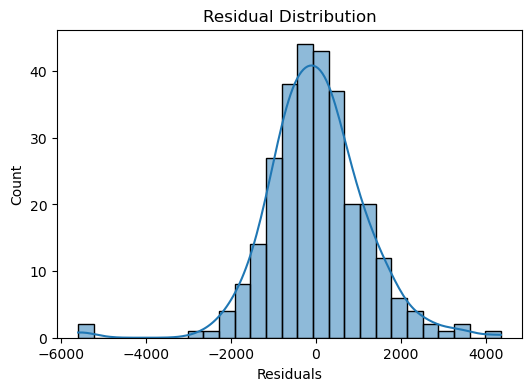

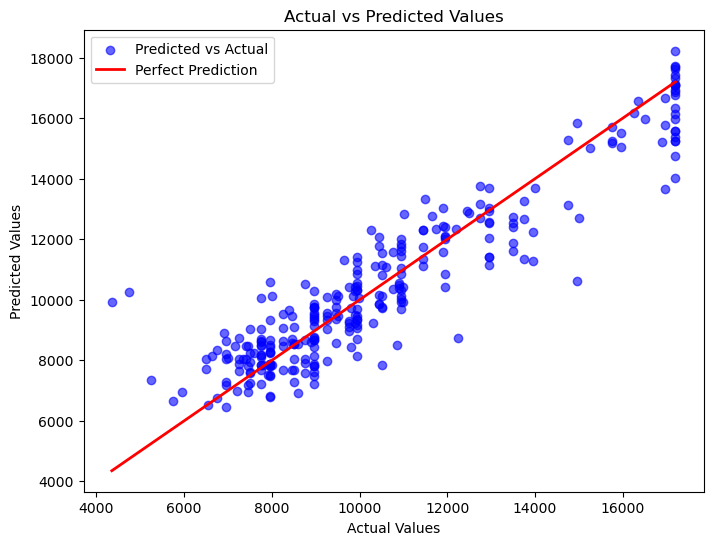

In [206]:
# Residual Analysis

import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals
residuals = Y_test - yhat_test

# Histogram of Residuals
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.show()

# Residuals vs Predicted
plt.figure(figsize=(8,6))
plt.scatter(Y_test, yhat_test, color='blue', alpha=0.6, label='Predicted vs Actual')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], color='red', linewidth=2, label='Perfect Prediction')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.legend()
plt.show()


### 5.Apply Lasso and Ridge methods on the model.


In [208]:
from sklearn.linear_model import Lasso, Ridge


In [210]:
# a. Lasso Regression - Linear Reg + L1 Regularisation
lasso = Lasso(alpha=1.0,)
lasso.fit(X,Y)

Lasso()

In [211]:
lasso.coef_

array([-1.07085588e+02, -1.46716906e-02,  2.83505388e+01,  0.00000000e+00,
       -2.55326753e+00, -1.01317706e+02,  0.00000000e+00,  0.00000000e+00,
        2.42603845e+01, -1.14604785e+03, -0.00000000e+00])

In [213]:
yhat_test=lasso.predict(x_test)
r2_score(Y_test,yhat_test)

0.864134781324724

In [212]:
# b. b. Ridge Regression - Linear Reg + L2 Regularisation
ridge = Ridge(alpha=1.0)
ridge.fit(X,Y)

Ridge()

In [214]:
yhat_test=ridge.predict(x_test)
r2_score(Y_test,yhat_test)

0.8641121319295182

## Interview Questions:


1.What is Normalization & Standardization and how is it helpful?

    Normalization: Converts values into a 0 to 1 range.
        Helps when features have very different scales.

    Standardization: Converts data to have mean = 0 and standard deviation = 1.
    Helps models learn faster and more accurately.

2.What techniques can be used to address multicollinearity in multiple linear regression?

   1. Remove highly correlated predictors,
   2. Combine correlated variables,
   3. Use Principal Component Analysis (PCA),
   4. Use Regularization methods like Ridge or Lasso Regression

